In [1]:
import os
CUDA_VISIBLE_DEVICES = "0,1"
os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['JAX_PLATFORM_NAME'] = 'gpu'

NPROC = len(CUDA_VISIBLE_DEVICES.split(","))

In [2]:
import tensorflow_datasets as tfds
import tensorflow as tf

batch_size = 32
epochs = 10

# load the MNIST dataset
ds_train: tf.data.Dataset = tfds.load("mnist", split="train", shuffle_files=True)
ds_train = ds_train.repeat(epochs).shuffle(1024).batch(batch_size).prefetch(1)

2025-04-19 15:06:25.201029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745075185.217174 2363560 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745075185.221966 2363560 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745075185.237544 2363560 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745075185.237566 2363560 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745075185.237570 2363560 computation_placer.cc:177] computation placer alr

In [3]:
import matplotlib.pyplot as plt

# samples = ds_train.as_numpy_iterator().next()
# # plot a 3x3 grid of the images using subplots
# fig, axs = plt.subplots(3, 3)
# for i in range(3):
#     for j in range(3):
#         axs[i, j].imshow(samples["image"][i * 3 + j, :, :, 0], cmap="gray")
#         axs[i, j].axis("off")

In [4]:
import jax
from jax.sharding import Mesh
from jax.sharding import PartitionSpec
from jax.sharding import NamedSharding
from jax.experimental import mesh_utils

P = PartitionSpec
mesh = Mesh(mesh_utils.create_device_mesh((NPROC,)), axis_names=('data',))

def with_mesh(f):
    def wrapper(*args, **kwargs):
        with mesh:
            return f(*args, **kwargs)
    return wrapper

# data: partition on batch axis
# model: partition feature axis

In [5]:
import flax.linen as nn
import jax
import jax.numpy as jnp

class Classifier(nn.Module):
    num_classes: int
    
    @nn.compact
    def __call__(self, x):
        hidden = nn.Dense(
            features=2**10,
            # kernel_init=nn.with_partitioning(
            #     nn.initializers.lecun_normal(), (None, 'data')
            # ),
            # bias_init=nn.with_partitioning(
            #     nn.initializers.zeros, (None,)
            # ),
            name='hidden',
        )
        x = x / 255.0
        x = x.reshape((x.shape[0], -1))  # flatten
        x = nn.relu(hidden(x))
        x = nn.Dense(features=self.num_classes, name='head')(x)
        return x

module = Classifier(num_classes=10)

variables = module.init(jax.random.PRNGKey(0), jnp.empty((1, 28, 28, 1)))
jax.tree_map(jnp.shape, variables)

/tmp/ipykernel_2363560/2126942208.py:29: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  jax.tree_map(jnp.shape, variables)


{'params': {'head': {'bias': (10,), 'kernel': (1024, 10)},
  'hidden': {'bias': (1024,), 'kernel': (784, 1024)}}}

In [6]:
from flax.training.train_state import TrainState
import optax
from functools import partial

@with_mesh
# @partial(jax.jit, static_argnums=(0,))
def create_state(module):
    variables = module.init(jax.random.PRNGKey(0), jnp.empty((1, 28, 28, 1)))
    state = TrainState.create(
        apply_fn=module.apply,
        params=variables["params"],
        tx=optax.adamw(1e-3),
    )
    state = jax.tree_map(jnp.asarray, state)
    state_spec = nn.get_partition_spec(state)
    state = jax.lax.with_sharding_constraint(state, state_spec)
    return state

state = create_state(module)
jax.tree_map(jnp.shape, state)

TrainState(step=(), apply_fn=<bound method Module.apply of Classifier(
    # attributes
    num_classes = 10
)>, params={'head': {'bias': (10,), 'kernel': (1024, 10)}, 'hidden': {'bias': (1024,), 'kernel': (784, 1024)}}, tx=GradientTransformationExtraArgs(init=<function chain.<locals>.init_fn at 0x7f1c0818e840>, update=<function chain.<locals>.update_fn at 0x7f1bcc195a80>), opt_state=(ScaleByAdamState(count=(), mu={'head': {'bias': (10,), 'kernel': (1024, 10)}, 'hidden': {'bias': (1024,), 'kernel': (784, 1024)}}, nu={'head': {'bias': (10,), 'kernel': (1024, 10)}, 'hidden': {'bias': (1024,), 'kernel': (784, 1024)}}), EmptyState(), EmptyState()))

In [7]:
jax.debug.visualize_array_sharding(state.params["hidden"]["kernel"])
jax.debug.visualize_array_sharding(state.params["head"]["kernel"])

                                
                                
                                
                                
                                
            GPU 0,1             
                                
                                
                                
                                
                                

         
         
         
         
         
 GPU 0,1 
         
         
         
         
         

In [8]:
from typing import Dict

def loss_fn(params, apply_fn, batch):
    logits = apply_fn({'params': params}, x=batch['image'])
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=batch['label']
    ).mean()
    return loss, logits

@with_mesh
@jax.jit
def train_step(state: TrainState, batch: Dict[str, jax.Array]):
    # state_spec = nn.get_partition_spec(state)

    batch = jax.lax.with_sharding_constraint(batch, P('data'))
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(state.params, state.apply_fn, batch)
    # grads = jax.lax.with_sharding_constraint(grads, state_spec.params)

    state = state.apply_gradients(grads=grads)

    logs = {
        'loss': loss,
        'accuracy': (jnp.argmax(logits, axis=-1) == batch['label']).mean()
    }
    # state = jax.lax.with_sharding_constraint(state, state_spec)
    return logs, state

In [9]:
from tqdm import tqdm
import numpy as np

state = create_state(module)
history = []
total_steps = ds_train.cardinality().numpy()

for batch in tqdm(ds_train.as_numpy_iterator(), total=total_steps):
    logs, state = train_step(state, batch)
    logs = jax.tree_map(np.asarray, logs)
    history.append(logs)

  0%|          | 0/18750 [00:00<?, ?it/s]

2025-04-19 15:06:37.224888: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
100%|██████████| 18750/18750 [00:24<00:00, 766.73it/s]


Text(0.5, 1.0, 'Accuracy')

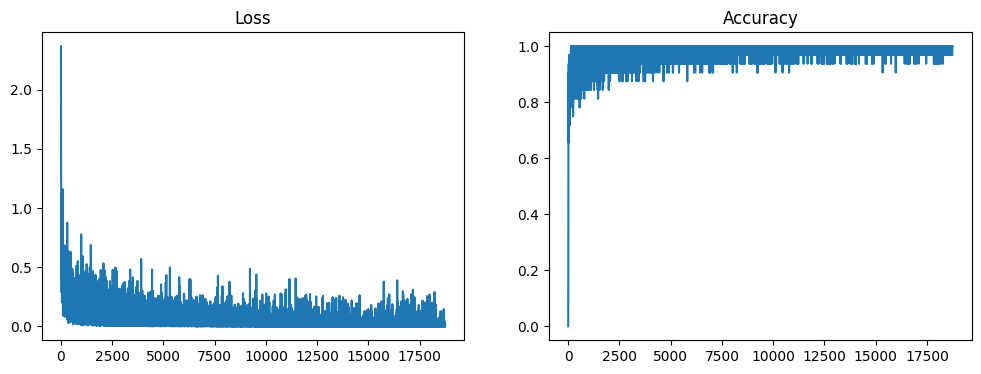

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot([h['loss'] for h in history])
axs[0].set_title('Loss')
axs[1].plot([h['accuracy'] for h in history])
axs[1].set_title('Accuracy')